In [2]:
import pandas as pd   # Data Processing
import numpy as np    # linear Algebra
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("Social_Network_Ads.csv")
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df = df.iloc[:,2:] #iloc -> when we have to use table by Index Integers
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
116,35,75000,0
159,32,135000,1
361,53,34000,1
276,38,71000,0
383,49,28000,1


# Train Test Split

In [6]:

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop('Purchased', axis = 1),
                                                       df['Purchased'],
                                                       test_size = 0.3,
                                                       random_state = 0)
x_train.shape , x_test.shape


#The drop method is used in this line of code to separate the feature data 
#(x_train, x_test) from the target variable data (y_train, y_test). 

((280, 2), (120, 2))

# StandardScaler




In [7]:
df_standardized_single_line = (df - df.mean()) / df.std()
df_standardized_single_line

,Age,EstimatedSalary,Purchased
0,-1.779569,-1.488183,-0.745003
1,-0.253270,-1.458854,-0.745003
2,-1.111813,-0.784307,-0.745003
3,-1.016419,-0.373714,-0.745003
4,-1.779569,0.183521,-0.745003
...,...,...,...
395,0.796060,-0.842964,1.338921
396,1.273028,-1.370870,1.338921
397,1.177635,-1.458854,1.338921
398,-0.157877,-1.077589,-0.745003


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameter
scaler.fit(x_train)

# transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


# we transform both train and test but learn from only train

In [9]:
scaler.mean_  # it will learn by itself and consider Age,EstimatedSalary as columns 
              #and give value as respective.

array([3.78642857e+01, 6.98071429e+04])

In [10]:
# StandardScaler will return Numpy Array
# so we have to convert them into pandas dataframe

x_train_scaled = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns = x_test.columns)

In [11]:
x_train_scaled   # this is scaled data 

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [12]:
np.round(x_train.describe(),1)  # original data with too much differnce in values 

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [13]:
np.round(x_train_scaled.describe(),1) # Scaled data with mean =1 ,std = 1

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of Scalling

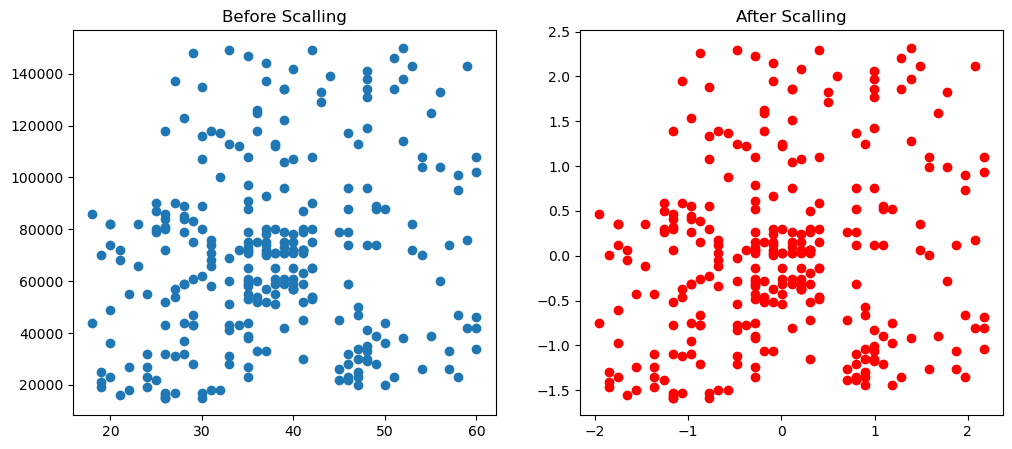

In [14]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))


ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title('Before Scalling')

ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color = 'red')
ax2.set_title('After Scalling')

plt.show()


# we can see directly Bfore we have mean near to 40 Now it is 0 with same stucture of data

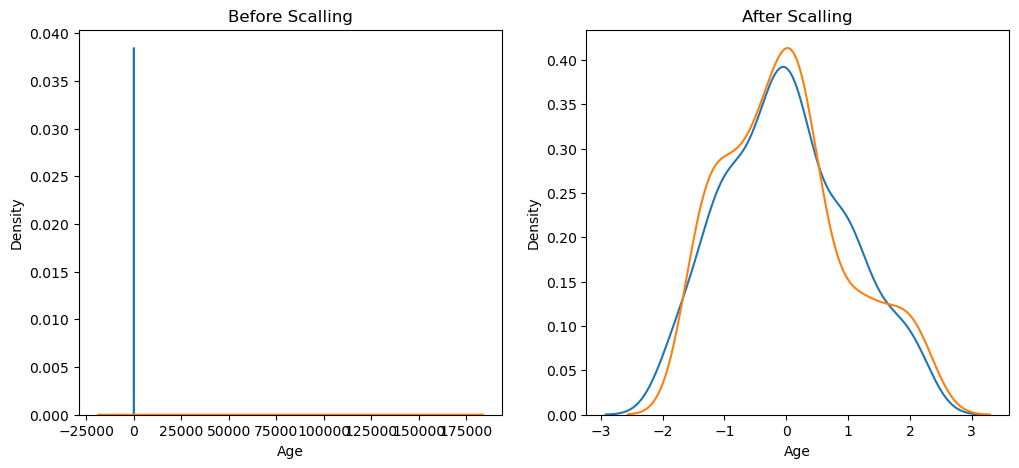

In [15]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))


## Drawing  PDF
# Before Scaling

ax1.set_title('Before Scalling')
sns.kdeplot(x_train['Age'], ax = ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax = ax1)


ax2.set_title('After Scalling')
sns.kdeplot(x_train_scaled['Age'], ax = ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax = ax2)

plt.show()

# in 1st Graph we can see as large value occurs graph is FLATE
# salaries bohot bade area me faile he to ekdam flat graph he , 
# vs age ekdam small range me he (20 - 60) so peak peform kiya

# Comparison Distribution

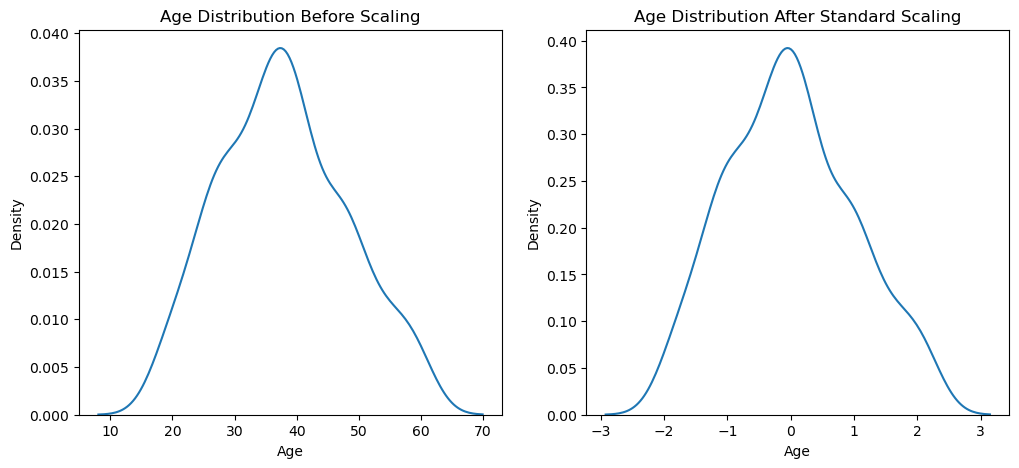

In [16]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
plt.show()

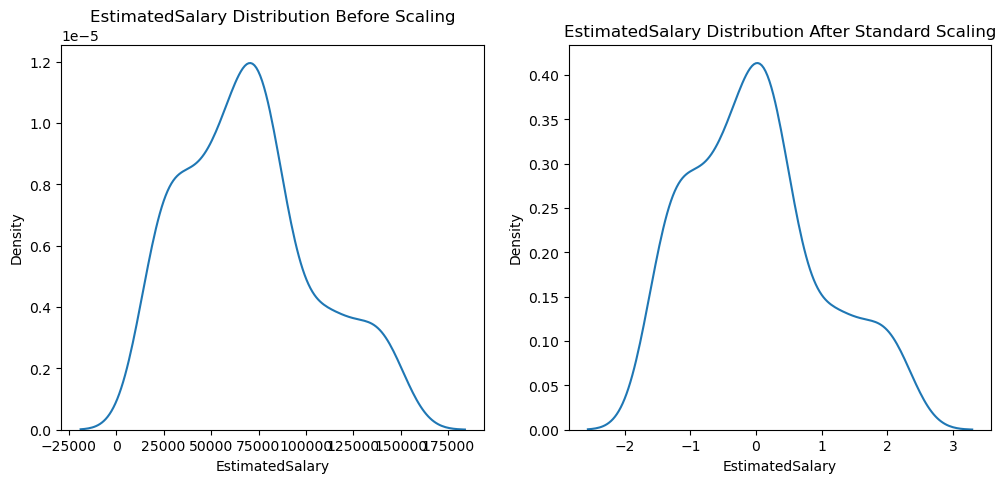

In [17]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('EstimatedSalary Distribution Before Scaling')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('EstimatedSalary Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Why Scaling is Important?

In [18]:
from sklearn.linear_model import LogisticRegression


In [19]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [20]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [21]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [22]:
from sklearn.metrics import accuracy_score

In [23]:
print("Actual", accuracy_score(y_test, y_pred))
print("Scaled", accuracy_score(y_test, y_pred_scaled))


Actual 0.875
Scaled 0.8666666666666667


## by Decision Tree Method

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()


In [26]:

dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

DecisionTreeClassifier()

In [27]:

y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [28]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [29]:
df.describe()


,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


# Effect of Outlier

In [30]:
other_df = pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})


df = pd.concat([df, other_df], ignore_index=True)


In [31]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


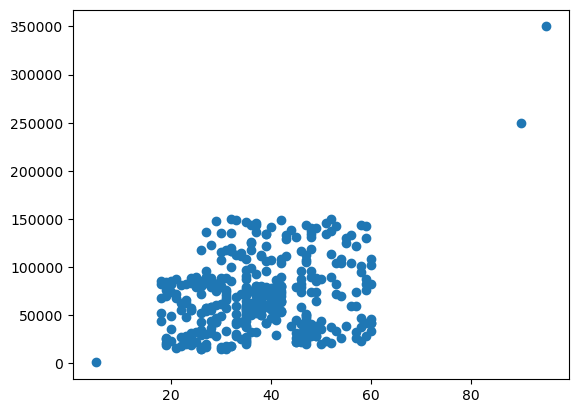

In [32]:

plt.scatter(df['Age'], df['EstimatedSalary'])

In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

x_train.shape, x_test.shape

((282, 2), (121, 2))

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

# transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [39]:

x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

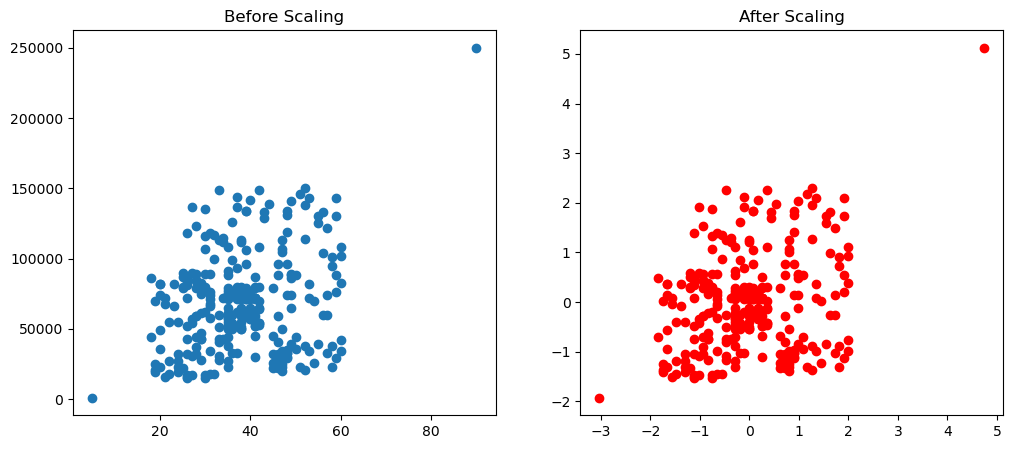

In [40]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()


# Our Learnings : We checking how outliers make differnce when we add 2 3 outlier's